# Customer Sales Analysis

## Objective
This project analyzes transactional sales data to identify revenue drivers, customer behavior, and profitability trends.

## Dataset
- 1,000,000 transactions
- Includes revenue, cost, profit, discounts, and customer/store data

## Key Questions
- Which products generate the most revenue?
- Who are the most valuable customers?
- How does revenue evolve over time?
- Do discounts affect profitability?

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("sales.csv")
df.head()

,order_id,order_date,product_id,store_id,customer_id,quantity,unit_price,discount,revenue,cost,profit
0,0RD00000001,2023-01-07,P0080,S093,C040749,5,14.43,0.15,61.33,42.77,18.56
1,0RD00000002,2023-10-22,P0173,S065,C020161,3,12.01,0.00,36.03,19.06,16.97
2,0RD00000003,2023-05-07,P0115,S078,C048069,2,10.02,0.00,20.04,10.29,9.75
3,0RD00000004,2024-06-23,P0186,S088,C047901,2,14.66,0.10,26.39,16.35,10.04
4,0RD00000005,2024-09-24,P0197,S054,C033950,1,12.34,0.00,12.34,7.94,4.40


In [ ]:
import os
print(os.getcwd())
print(os.listdir())

In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 11 columns):
 #   Column       Non-Null Count    Dtype  
---  ------       --------------    -----  
 0   order_id     1000000 non-null  str    
 1   order_date   1000000 non-null  str    
 2   product_id   1000000 non-null  str    
 3   store_id     1000000 non-null  str    
 4   customer_id  1000000 non-null  str    
 5   quantity     1000000 non-null  int64  
 6   unit_price   1000000 non-null  float64
 7   discount     1000000 non-null  float64
 8   revenue      1000000 non-null  float64
 9   cost         1000000 non-null  float64
 10  profit       1000000 non-null  float64
dtypes: float64(5), int64(1), str(5)
memory usage: 119.2 MB


In [3]:
df["order_date"] = pd.to_datetime(df["order_date"])

In [4]:
print("Total Revenue:", round(df["revenue"].sum(), 2))
print("Total Profit:", round(df["profit"].sum(), 2))
print("Average Order Value:", round(df["revenue"].mean(), 2))
print("Total Orders:", df["order_id"].nunique())
print("Total Customers:", df["customer_id"].nunique())

Total Revenue: 25486128.86
Total Profit: 10194564.63
Average Order Value: 25.49
Total Orders: 1000000
Total Customers: 50000


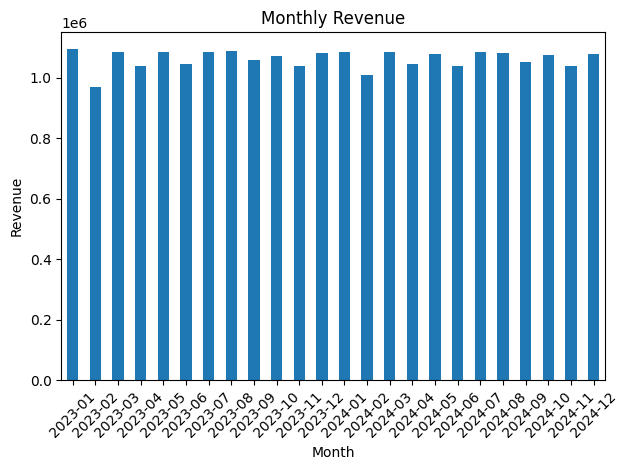

In [5]:
monthly_revenue = df.groupby(df["order_date"].dt.to_period("M"))["revenue"].sum()
monthly_revenue.index = monthly_revenue.index.astype(str)

monthly_revenue.plot(kind="bar")
plt.title("Monthly Revenue")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

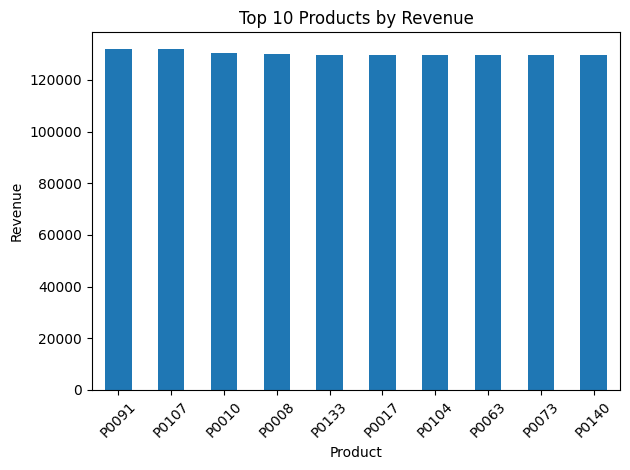

In [6]:
top_products = df.groupby("product_id")["revenue"].sum().sort_values(ascending=False)

top_products.head(10).plot(kind="bar")
plt.title("Top 10 Products by Revenue")
plt.xlabel("Product")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

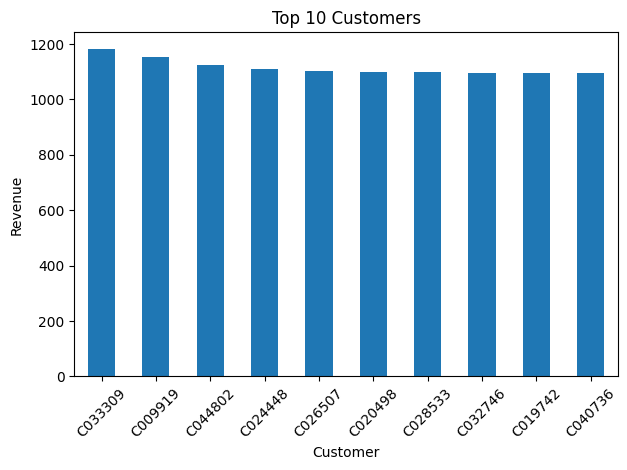

In [7]:
top_customers = df.groupby("customer_id")["revenue"].sum().sort_values(ascending=False)

top_customers.head(10).plot(kind="bar")
plt.title("Top 10 Customers")
plt.xlabel("Customer")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

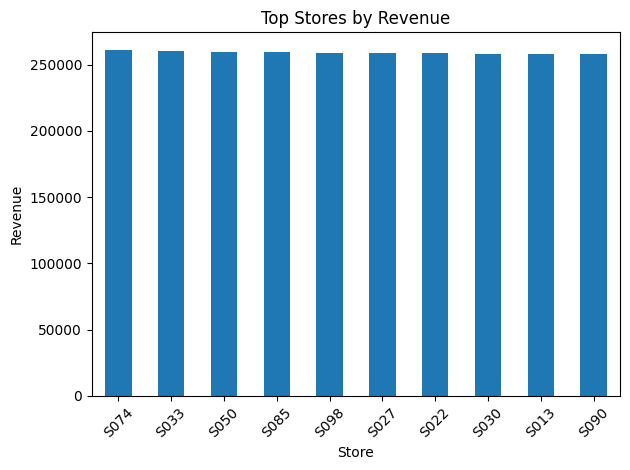

In [8]:
store_perf = df.groupby("store_id")["revenue"].sum().sort_values(ascending=False)

store_perf.head(10).plot(kind="bar")
plt.title("Top Stores by Revenue")
plt.xlabel("Store")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

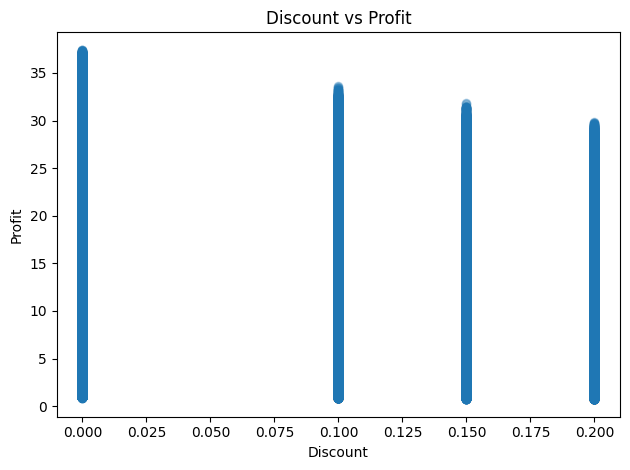

In [9]:
plt.scatter(df["discount"], df["profit"], alpha=0.3)
plt.title("Discount vs Profit")
plt.xlabel("Discount")
plt.ylabel("Profit")
plt.tight_layout()
plt.show()

## Key Insights

- Revenue varies significantly across products and customers, indicating concentration in top performers.
- A small number of customers contribute a large portion of total revenue.
- Some stores outperform others, suggesting operational differences.
- Discounts may negatively impact profitability if not controlled.
- Monthly revenue trends indicate potential seasonality.

## Business Recommendations

- Focus on top-performing products and customers.
- Optimize discount strategies to protect profit margins.
- Analyze high-performing stores to replicate success.
- Use time trends for forecasting and planning.

<Axes: xlabel='product_id'>

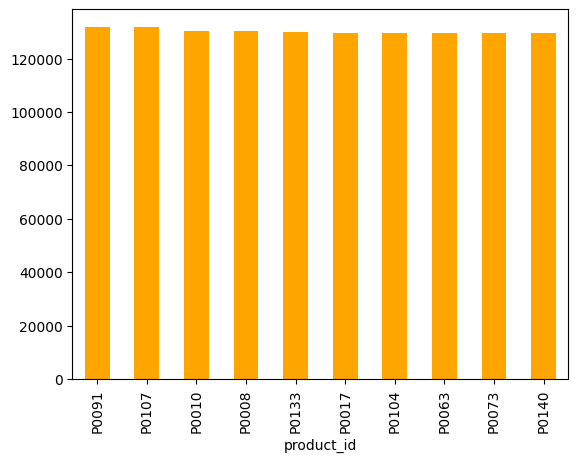

In [10]:
top_products.head(10).plot(kind="bar", color="orange")

<Axes: xlabel='customer_id'>

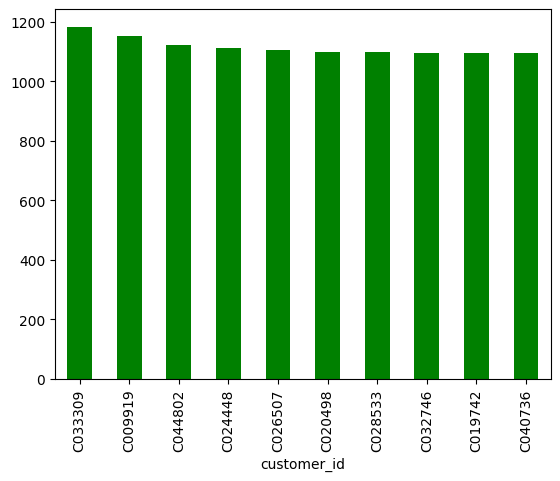

In [11]:
top_customers.head(10).plot(kind="bar", color="green")

<Axes: xlabel='store_id'>

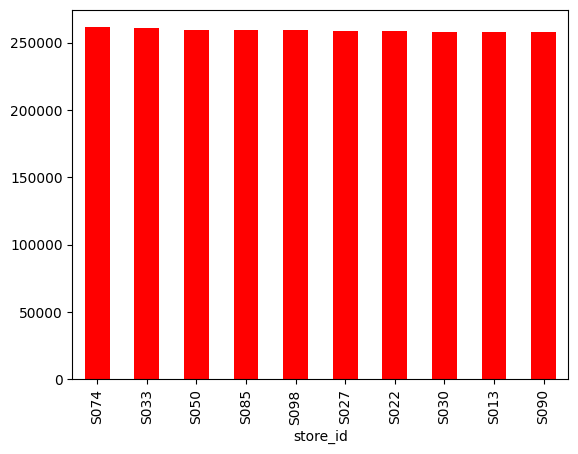

In [12]:
store_perf.head(10).plot(kind="bar", color="red")

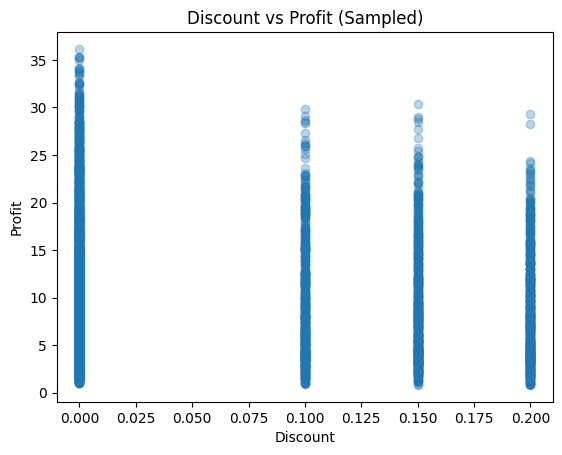

In [13]:
sample_df = df.sample(5000)

plt.scatter(sample_df["discount"], sample_df["profit"], alpha=0.3)
plt.title("Discount vs Profit (Sampled)")
plt.xlabel("Discount")
plt.ylabel("Profit")
plt.show()

(array([-5.,  0.,  5., 10., 15., 20., 25.]),
 [Text(-5.0, 0, '2024-08'),
  Text(0.0, 0, '2023-01'),
  Text(5.0, 0, '2023-06'),
  Text(10.0, 0, '2023-11'),
  Text(15.0, 0, '2024-04'),
  Text(20.0, 0, '2024-09'),
  Text(25.0, 0, '')])

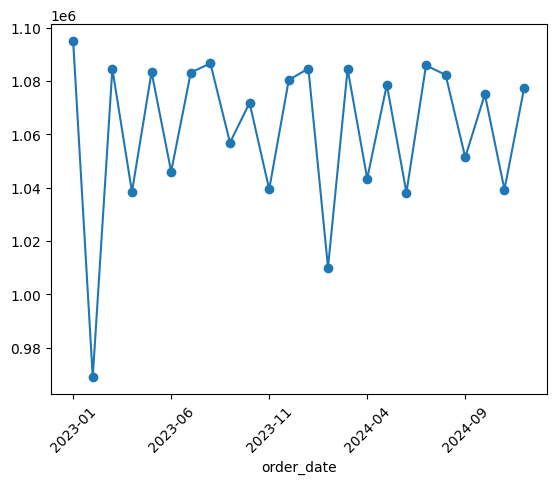

In [14]:
monthly_revenue.plot(kind="line", marker="o")
plt.xticks(rotation=45)

In [15]:
import os
print(os.getcwd())

C:\Users\kcirt\Rick AI Labs
